In [4]:
# Alternative download for Windows (using Python requests and zipfile)
import requests, zipfile, io
def download_and_extract(url, extract_to):
    print(f"Downloading {url}...")
    r = requests.get(url, stream=True)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(extract_to)
    print(f"Extracted to {extract_to}")

# Download val2017 images
if not os.path.exists('val2017'):
    download_and_extract('http://images.cocodataset.org/zips/val2017.zip', './val2017')

# Download annotations
if not os.path.exists('annotations'):
    download_and_extract('http://images.cocodataset.org/annotations/annotations_trainval2017.zip', './annotations')

Extracted to ./val2017
Extracted to ./annotations


In [2]:
# Install required packages for COCO and YOLOv8
%pip install pycocotools ultralytics pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.3 MB/s eta 0:00:00


# COCO Dataset Pose Demo
Notebook này giúp bạn làm việc với COCO dataset mà không cần upload dataset, vì COCO đã có sẵn.
Bạn sẽ học cách load, khám phá, hiển thị ảnh và annotation, filter theo category, và visualize bounding box/segmentation.

## 1. Import Required Libraries
Chúng ta sẽ import các thư viện cần thiết để làm việc với COCO: numpy, matplotlib, pycocotools, ultralytics (YOLOv8).

In [3]:
# Import essential libraries
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Load COCO Dataset
Chúng ta sẽ load annotation COCO (person keypoints) từ file có sẵn.

In [5]:
# Load COCO dataset annotations (person keypoints)
coco_annotation_path = 'annotations/annotations/person_keypoints_val2017.json'
coco = COCO(coco_annotation_path)

loading annotations into memory...
Done (t=0.25s)
creating index...
index created!


## 3. Explore COCO Dataset Structure
Khám phá cấu trúc dataset: categories, images, annotations.

In [6]:
# Explore COCO structure
categories = coco.loadCats(coco.getCatIds())
print('Categories:', [cat['name'] for cat in categories])
image_ids = coco.getImgIds()
print('Total images:', len(image_ids))
ann_ids = coco.getAnnIds()
print('Total annotations:', len(ann_ids))

Categories: ['person']
Total images: 5000
Total annotations: 11004


## 4. Display Sample Images and Annotations
Hiển thị một số ảnh và annotation keypoints từ COCO.

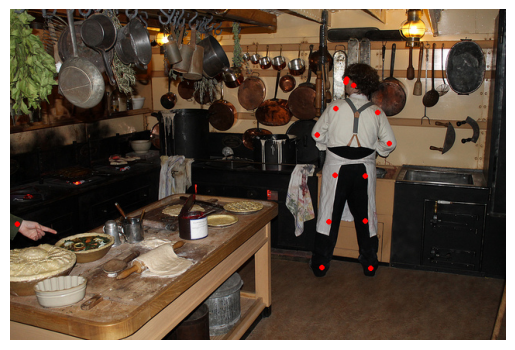

In [7]:
# Display sample image and keypoints
import requests
from PIL import Image, ImageDraw
sample_img_id = image_ids[0]
img_info = coco.loadImgs(sample_img_id)[0]
img_url = img_info['coco_url']
img = Image.open(requests.get(img_url, stream=True).raw)
ann_ids = coco.getAnnIds(imgIds=sample_img_id)
anns = coco.loadAnns(ann_ids)
draw = ImageDraw.Draw(img)
for ann in anns:
    if 'keypoints' in ann:
        kps = ann['keypoints']
        for i in range(0, len(kps), 3):
            x, y, v = kps[i], kps[i+1], kps[i+2]
            if v > 0:
                draw.ellipse((x-3, y-3, x+3, y+3), fill='red')
plt.imshow(img)
plt.axis('off')
plt.show()

## 5. Filter Images by Category
Lọc ảnh theo category (ví dụ: person) bằng COCO API.

In [8]:
# Filter images by category (person)
person_cat_id = coco.getCatIds(catNms=['person'])[0]
person_img_ids = coco.getImgIds(catIds=[person_cat_id])
print('Number of person images:', len(person_img_ids))

Number of person images: 2693


## 6. Visualize Bounding Boxes and Segmentation
Hiển thị bounding box và segmentation mask trên ảnh mẫu.

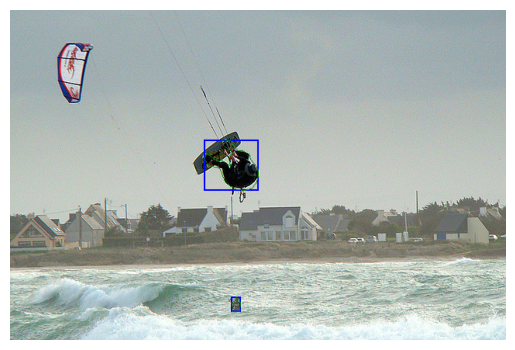

In [9]:
# Visualize bounding boxes and segmentation masks
sample_img_id = person_img_ids[0]
img_info = coco.loadImgs(sample_img_id)[0]
img_url = img_info['coco_url']
img = Image.open(requests.get(img_url, stream=True).raw)
ann_ids = coco.getAnnIds(imgIds=sample_img_id, catIds=[person_cat_id])
anns = coco.loadAnns(ann_ids)
draw = ImageDraw.Draw(img)
for ann in anns:
    # Draw bounding box
    if 'bbox' in ann:
        x, y, w, h = ann['bbox']
        draw.rectangle([x, y, x+w, y+h], outline='blue', width=2)
    # Draw segmentation mask (if exists)
    if 'segmentation' in ann and isinstance(ann['segmentation'], list):
        for seg in ann['segmentation']:
            draw.polygon(seg, outline='green')
plt.imshow(img)
plt.axis('off')
plt.show()

In [10]:
import json
import os

coco_json = 'annotations/annotations/person_keypoints_val2017.json'
images_dir = 'val2017/images'
labels_dir = 'val2017/labels'

os.makedirs(labels_dir, exist_ok=True)

with open(coco_json, 'r') as f:
    coco = json.load(f)

# map image info
img_info = {img['id']: img for img in coco['images']}

for ann in coco['annotations']:

    if ann['category_id'] != 1:
        continue

    img_id = ann['image_id']
    keypoints = ann['keypoints']
    bbox = ann['bbox']

    img = img_info[img_id]
    img_w = img['width']
    img_h = img['height']

    # bbox
    x, y, w, h = bbox
    xc = (x + w/2) / img_w
    yc = (y + h/2) / img_h
    w /= img_w
    h /= img_h

    # keypoints
    kpts = []
    for i in range(0, len(keypoints), 3):
        xk = keypoints[i] / img_w
        yk = keypoints[i+1] / img_h
        v = keypoints[i+2]

        kpts.extend([xk, yk, v])

    filename = img['file_name'].replace('.jpg', '.txt')
    label_path = os.path.join(labels_dir, filename)

    with open(label_path, 'a') as f:
        f.write(f"0 {xc} {yc} {w} {h} {' '.join(map(str, kpts))}\n")

In [11]:
import os

images_dir = 'val2017/images'
labels_dir = 'val2017/labels'

image_files = [os.path.splitext(f)[0] for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]
label_files = [os.path.splitext(f)[0] for f in os.listdir(labels_dir) if f.endswith('.txt')]

missing_labels = set(image_files) - set(label_files)

for img_name in missing_labels:
    open(os.path.join(labels_dir, img_name + '.txt'), 'w').close()  # Tạo file nhãn trống

print(f"Đã tạo {len(missing_labels)} file nhãn trống.")

Đã tạo 2307 file nhãn trống.


In [12]:
import os

labels_dir = 'val2017/labels'
valid_count = 0
for fname in os.listdir(labels_dir):
    with open(os.path.join(labels_dir, fname)) as f:
        lines = f.readlines()
        for line in lines:
            nums = line.strip().split()
            if len(nums) == 39:
                valid_count += 1
print(f"Số file nhãn hợp lệ: {valid_count}")

Số file nhãn hợp lệ: 0


## 7. Train YOLOv8n-pose on COCO
Huấn luyện model YOLOv8n-pose.pt trên COCO keypoints dataset.

In [13]:
# Check google colab is using CPU or GPU
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [17]:
# Train YOLOv8n-pose.pt on COCO keypoints dataset
from ultralytics import YOLO
import os
pose_model = 'yolov8n-pose.pt'
coco_yaml = 'coco_keypoints.yaml'  # Update to your COCO YAML config
epochs = 10
batch = 8
imgsz = 640
workers = 4
patience = 20
run_name = 'coco_pose_demo'

# Check file existence before training
print('File model tồn tại:', os.path.exists(pose_model))
print('File yaml tồn tại:', os.path.exists(coco_yaml))

if os.path.exists(pose_model) and os.path.exists(coco_yaml):
    model = YOLO(pose_model)
    results = model.train(
        data=coco_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        name=run_name,
        exist_ok=True
    )
    print("\n✅ Training completed!")
else:
    print("❌ yolov8n-pose.pt hoặc coco_keypoints.yaml chưa có!")
    print("Vui lòng tải model và tạo file cấu hình YAML cho COCO keypoints.")

File model tồn tại: True
File yaml tồn tại: True
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco_keypoints.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/pose/coco_pose_demo/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coco_pose_demo_V2, nbs=64, nms=False, opset=Non

KeyboardInterrupt: 

In [ ]:
# Convert YOLOv8 pose model sang OpenVINO IR sau khi train xong
from ultralytics import YOLO
import os
# Tự động lấy best.pt từ thư mục weights
weights_dir = 'runs/pose/coco_pose_demo/weights'
pose_model = os.path.join(weights_dir, 'best.pt')
output_dir = 'runs/pose/coco_pose_demo/weights/best_openvino_model'
os.makedirs(output_dir, exist_ok=True)
model = YOLO(pose_model)
model.export(format='openvino')
print(f'Model exported to OpenVINO IR in {output_dir}')

Ultralytics 8.4.19  Python-3.12.10 torch-2.10.0+cpu CPU (Intel Core Ultra 5 225H)
YOLOv8n-pose summary (fused): 82 layers, 3,289,964 parameters, 0 gradients, 9.2 GFLOPs

PyTorch: starting from 'runs\pose\coco_pose_demo\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 56, 2100) (6.5 MB)

OpenVINO: starting export with openvino 2026.0.0-20965-c6d6a13a886-releases/2026/0...
OpenVINO: export success  1.5s, saved as 'runs\pose\coco_pose_demo\weights\best_openvino_model\' (12.9 MB)

Export complete (1.6s)
Results saved to D:\Detect_traffic_sign\Pose_estimate\runs\pose\coco_pose_demo\weights
Predict:         yolo predict task=pose model=runs\pose\coco_pose_demo\weights\best_openvino_model imgsz=320 
Validate:        yolo val task=pose model=runs\pose\coco_pose_demo\weights\best_openvino_model imgsz=320 data=d:/Detect_traffic_sign/Pose_estimate/coco_keypoints.yaml  
Visualize:       https://netron.app
Model exported to OpenVINO IR in runs/pose/coco_pose_demo/weig